In [2]:
import json
from pathlib import Path

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Find project root reliably whether notebook is launched from project root or training folder.
candidate_roots = [
    Path.cwd(),
    Path.cwd().parent,
    Path(r"D:/ML_project/Tomato_Disease_Detection"),
]
PROJECT_ROOT = None
for root in candidate_roots:
    if (root / "Data_sets_split").exists():
        PROJECT_ROOT = root
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate project root containing Data_sets_split")

DATA_ROOT = PROJECT_ROOT / "Data_sets_split"
TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "validation"
TEST_DIR = DATA_ROOT / "test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 40
PASS_ACCURACY = 0.85

# Recommended for scratch training. If convergence is too slow, try 3e-4.
INITIAL_LR = 1e-4

# Keep previous production artifact untouched by saving to a new filename.
SCRATCH_MODEL_PATH = PROJECT_ROOT / "trained_model" / "new_tomato_disease_model_scratch_v1.h5"
SCRATCH_CLASS_INDICES_PATH = PROJECT_ROOT / "training" / "class_indices_scratch_v1.json"

print(f"Project root: {PROJECT_ROOT}")
print(f"Train dir: {TRAIN_DIR}")
print(f"Validation dir: {VAL_DIR}")
print(f"Test dir: {TEST_DIR}")
print(f"Scratch model path: {SCRATCH_MODEL_PATH}")
print(f"Scratch class-indices path: {SCRATCH_CLASS_INDICES_PATH}")

Project root: d:\ML_project\Tomato_Disease_Detection
Train dir: d:\ML_project\Tomato_Disease_Detection\Data_sets_split\train
Validation dir: d:\ML_project\Tomato_Disease_Detection\Data_sets_split\validation
Test dir: d:\ML_project\Tomato_Disease_Detection\Data_sets_split\test
Scratch model path: d:\ML_project\Tomato_Disease_Detection\trained_model\new_tomato_disease_model_scratch_v1.h5
Scratch class-indices path: d:\ML_project\Tomato_Disease_Detection\training\class_indices_scratch_v1.json


In [3]:
# Sanity checks before creating generators
for p in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    if not p.exists():
        raise FileNotFoundError(f"Missing dataset folder: {p}")

train_classes = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
val_classes = sorted([d.name for d in VAL_DIR.iterdir() if d.is_dir()])
test_classes = sorted([d.name for d in TEST_DIR.iterdir() if d.is_dir()])

print(f"Train classes ({len(train_classes)}):", train_classes)
print(f"Validation classes ({len(val_classes)}):", val_classes)
print(f"Test classes ({len(test_classes)}):", test_classes)

if not (train_classes == val_classes == test_classes):
    raise ValueError("Class folders are inconsistent across train/validation/test")

print("Dataset directory structure looks valid.")

Train classes (10): ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']
Validation classes (10): ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']
Test classes (10): ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']
Dataset directory structure looks valid.


In [4]:
# Data preprocessing and augmentation policy matches train_mobilenet.ipynb
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
)

val_datagen = ImageDataGenerator(rescale=1.0 / 255)
test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
)

validation_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False,
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False,
)

print(f"Training samples:   {train_generator.samples}")
print(f"Validation samples: {validation_generator.samples}")
print(f"Test samples:       {test_generator.samples}")
print(f"Number of classes:  {train_generator.num_classes}")
print("Class indices:", train_generator.class_indices)

with open(SCRATCH_CLASS_INDICES_PATH, "w", encoding="utf-8") as f:
    json.dump(train_generator.class_indices, f, indent=2)

print(f"Saved scratch class indices to: {SCRATCH_CLASS_INDICES_PATH}")

Found 8713 images belonging to 10 classes.
Found 2902 images belonging to 10 classes.
Found 2914 images belonging to 10 classes.
Training samples:   8713
Validation samples: 2902
Test samples:       2914
Number of classes:  10
Class indices: {'Tomato___Bacterial_spot': 0, 'Tomato___Early_blight': 1, 'Tomato___Late_blight': 2, 'Tomato___Leaf_Mold': 3, 'Tomato___Septoria_leaf_spot': 4, 'Tomato___Spider_mites': 5, 'Tomato___Target_Spot': 6, 'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 7, 'Tomato___Tomato_mosaic_virus': 8, 'Tomato___healthy': 9}
Saved scratch class indices to: d:\ML_project\Tomato_Disease_Detection\training\class_indices_scratch_v1.json


In [5]:
def build_scratch_cnn(input_shape=(224, 224, 3), num_classes=10):
    model = Sequential(
        [
            Conv2D(32, (3, 3), padding="same", activation="relu", input_shape=input_shape),
            BatchNormalization(),
            MaxPooling2D((2, 2)),
            Dropout(0.20),

            Conv2D(64, (3, 3), padding="same", activation="relu"),
            BatchNormalization(),
            MaxPooling2D((2, 2)),
            Dropout(0.25),

            Conv2D(128, (3, 3), padding="same", activation="relu"),
            BatchNormalization(),
            MaxPooling2D((2, 2)),
            Dropout(0.30),

            Conv2D(256, (3, 3), padding="same", activation="relu"),
            BatchNormalization(),
            MaxPooling2D((2, 2)),
            Dropout(0.35),

            Flatten(),
            Dense(256, activation="relu"),
            Dropout(0.40),
            Dense(num_classes, activation="softmax"),
        ]
    )
    return model

model = build_scratch_cnn(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), num_classes=train_generator.num_classes)

model.compile(
    optimizer=Adam(learning_rate=INITIAL_LR),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()
print(f"Compiled with Adam learning rate: {INITIAL_LR}")
print("If needed later, you can recompile with Adam(learning_rate=1e-5) for slower, finer updates.")



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 224, 224, 32)      896       
                                                                 
 batch_normalization (Batch  (None, 224, 224, 32)      128       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 112, 112, 32)      0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 112, 112, 32)      0         
                                                                 
 conv2d_1 (Conv2D)           (None, 112, 112, 64)      18496     
                                                                 
 batch_normalization_1 (Bat  (None, 112, 112, 64)     

In [6]:
best_ckpt_path = PROJECT_ROOT / "trained_model" / "new_tomato_disease_model_scratch_v1_best.keras"

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
    ),
    ModelCheckpoint(
        filepath=str(best_ckpt_path),
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1,
    ),
]

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
)

print(f"Best checkpoint saved to: {best_ckpt_path}")

Epoch 1/40


273/273 [==============================] - ETA: 0s - loss: 1.6270 - accuracy: 0.4805
Epoch 1: val_loss improved from inf to 11.85884, saving model to d:\ML_project\Tomato_Disease_Detection\trained_model\new_tomato_disease_model_scratch_v1_best.keras
273/273 [==============================] - 500s 2s/step - loss: 1.6270 - accuracy: 0.4805 - val_loss: 11.8588 - val_accuracy: 0.3687 - lr: 1.0000e-04
Epoch 2/40
273/273 [==============================] - ETA: 0s - loss: 1.1359 - accuracy: 0.6175
Epoch 2: val_loss improved from 11.85884 to 5.30993, saving model to d:\ML_project\Tomato_Disease_Detection\trained_model\new_tomato_disease_model_scratch_v1_best.keras
273/273 [==============================] - 405s 1s/step - loss: 1.1359 - accuracy: 0.6175 - val_loss: 5.3099 - val_accuracy: 0.4793 - lr: 1.0000e-04
Epoch 3/40
273/273 [==============================] - ETA: 0s - loss: 0.9930 - accuracy: 0.6630
Epoch 3: val_loss improved from 5.30993 to 2.79460, saving model to d:\ML_pro

In [7]:
# Save final scratch model artifact (keeps previous production model untouched)
SCRATCH_MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
model.save(SCRATCH_MODEL_PATH)
print(f"Saved scratch model to: {SCRATCH_MODEL_PATH}")

d:\ML_project\Tomato_Disease_Detection\venv\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Saved scratch model to: d:\ML_project\Tomato_Disease_Detection\trained_model\new_tomato_disease_model_scratch_v1.h5


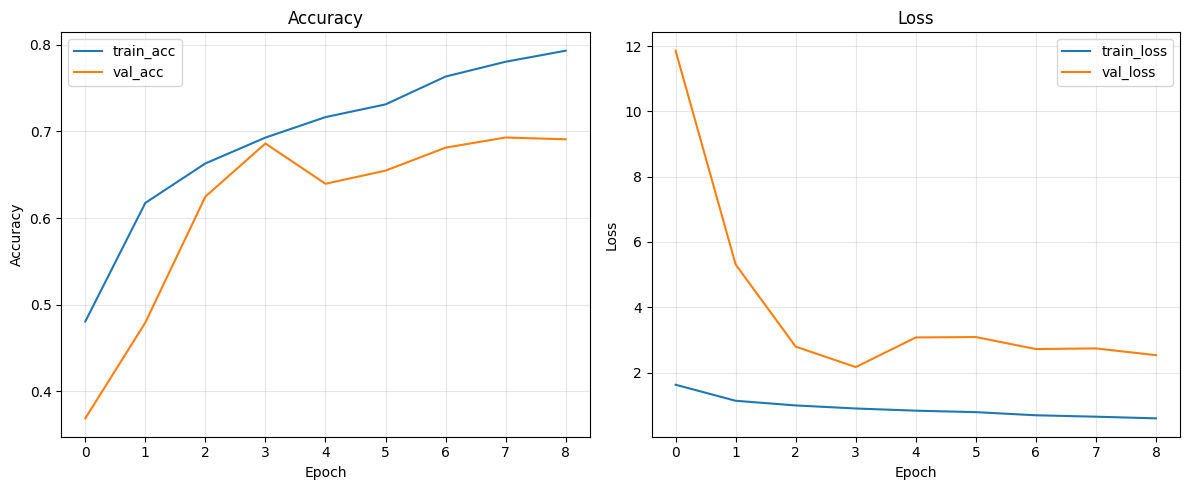

In [8]:
# Plot training history
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

92/92 [==============================] - 49s 532ms/step - loss: 2.1262 - accuracy: 0.6850
Test Loss: 2.1262
Test Accuracy: 68.50%
92/92 [==============================] - 29s 314ms/step

Classification Report:
                                        precision    recall  f1-score   support

               Tomato___Bacterial_spot     0.7751    0.7683    0.7717       341
                 Tomato___Early_blight     0.0000    0.0000    0.0000       160
                  Tomato___Late_blight     0.7273    0.4706    0.5714       306
                    Tomato___Leaf_Mold     0.9744    0.2484    0.3958       153
           Tomato___Septoria_leaf_spot     0.6271    0.5211    0.5692       284
                 Tomato___Spider_mites     0.4677    0.8625    0.6065       269
                  Tomato___Target_Spot     0.5214    0.2699    0.3557       226
Tomato___Tomato_Yellow_Leaf_Curl_Virus     0.7661    0.9848    0.8618       858
          Tomato___Tomato_mosaic_virus     0.4167    0.1639    0.2353

d:\ML_project\Tomato_Disease_Detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\ML_project\Tomato_Disease_Detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\ML_project\Tomato_Disease_Detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

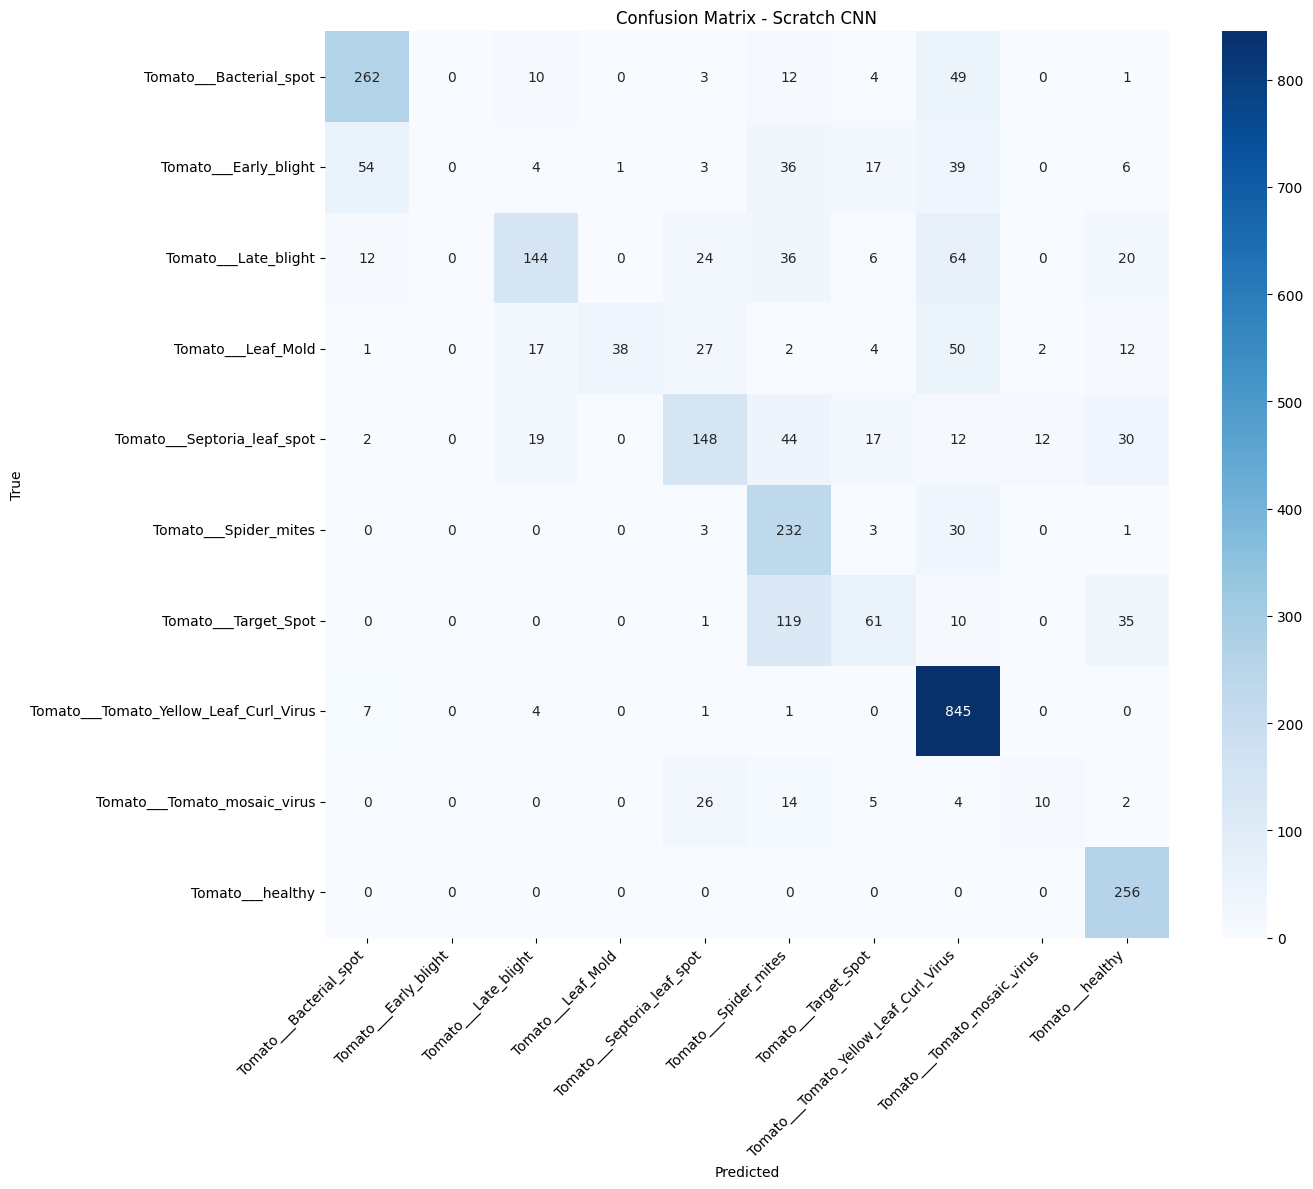


Per-class recall:
- Tomato___Bacterial_spot                      :  76.83% ( 341 samples)
- Tomato___Early_blight                        :   0.00% ( 160 samples)
- Tomato___Late_blight                         :  47.06% ( 306 samples)
- Tomato___Leaf_Mold                           :  24.84% ( 153 samples)
- Tomato___Septoria_leaf_spot                  :  52.11% ( 284 samples)
- Tomato___Spider_mites                        :  86.25% ( 269 samples)
- Tomato___Target_Spot                         :  26.99% ( 226 samples)
- Tomato___Tomato_Yellow_Leaf_Curl_Virus       :  98.48% ( 858 samples)
- Tomato___Tomato_mosaic_virus                 :  16.39% (  61 samples)
- Tomato___healthy                             : 100.00% ( 256 samples)


In [9]:
# Evaluate on test split
test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)
print("=" * 70)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print("=" * 70)

# Classification report and confusion matrix
test_generator.reset()
y_prob = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_prob, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title("Confusion Matrix - Scratch CNN")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Per-class recall summary
print("\nPer-class recall:")
for idx, class_name in enumerate(class_names):
    class_mask = y_true == idx
    class_total = int(class_mask.sum())
    if class_total == 0:
        print(f"- {class_name}: no samples")
        continue
    class_recall = float((y_pred[class_mask] == y_true[class_mask]).sum() / class_total)
    print(f"- {class_name:45s}: {class_recall * 100:6.2f}% ({class_total:4d} samples)")

In [11]:
# Final decision block (candidate for later promotion)
print("\n" + "=" * 70)
print("SCRATCH MODEL READINESS DECISION")
print("=" * 70)
print(f"Acceptance rule: test_accuracy >= {PASS_ACCURACY * 100:.2f}%")
print(f"Observed test_accuracy: {test_accuracy * 100:.2f}%")

if test_accuracy >= PASS_ACCURACY:
    print("FINAL DECISION: PASS")
    print(f"Candidate model is ready for later replacement: {SCRATCH_MODEL_PATH}")
else:
    print("FINAL DECISION: FAIL")
    print("Keep iterating on architecture/epochs/regularization before replacement.")

print("Current production model remains untouched.")
print("=" * 70)


SCRATCH MODEL READINESS DECISION
Acceptance rule: test_accuracy >= 85.00%
Observed test_accuracy: 68.50%
FINAL DECISION: FAIL
Keep iterating on architecture/epochs/regularization before replacement.
Current production model remains untouched.


In [ ]:
# Optional: recompile with smaller LR exactly as requested before a fine-tuning continuation run
# Use only after initial convergence, not as the very first compile from random init.
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
print("Model recompiled with Adam(learning_rate=1e-5)")

### V2 Improvement Run (Class Weights + Fine-Tuning)

This section keeps the previous run untouched and trains a stronger scratch CNN with:
- lighter classifier head using GlobalAveragePooling2D (better generalization than large Flatten head)
- class weights for class-imbalance handling
- two-stage optimization:
  1. warmup training at `Adam(1e-4)`
  2. fine-tuning continuation at `Adam(1e-5)`

Target remains: `test_accuracy >= 85%`.

In [12]:
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.regularizers import l2

# Versioned artifact names so production artifact remains untouched.
SCRATCH_V2_MODEL_PATH = PROJECT_ROOT / "trained_model" / "new_tomato_disease_model_scratch_v2.h5"
SCRATCH_V2_BEST_PATH = PROJECT_ROOT / "trained_model" / "new_tomato_disease_model_scratch_v2_best.keras"

# Compute class weights from training labels to improve weaker classes.
train_labels = train_generator.classes
class_ids = np.unique(train_labels)
weights = compute_class_weight(class_weight="balanced", classes=class_ids, y=train_labels)
class_weight = {int(c): float(w) for c, w in zip(class_ids, weights)}

print("Class weight map:")
for cidx, w in class_weight.items():
    print(f"- {cidx}: {w:.4f}")

V2_STAGE1_EPOCHS = 20
V2_STAGE2_EPOCHS = 15

Class weight map:
- 0: 0.8534
- 1: 1.8152
- 2: 0.9512
- 3: 1.9107
- 4: 1.0251
- 5: 1.0837
- 6: 1.2947
- 7: 0.3389
- 8: 4.8676
- 9: 1.1419


In [13]:
def build_scratch_cnn_v2(input_shape=(224, 224, 3), num_classes=10):
    model_v2 = Sequential([
        Conv2D(32, (3, 3), padding="same", activation="relu", input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.20),

        Conv2D(64, (3, 3), padding="same", activation="relu"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        Conv2D(128, (3, 3), padding="same", activation="relu"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.30),

        Conv2D(256, (3, 3), padding="same", activation="relu"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.35),

        GlobalAveragePooling2D(),
        Dense(256, activation="relu", kernel_regularizer=l2(1e-4)),
        Dropout(0.45),
        Dense(num_classes, activation="softmax"),
    ])
    return model_v2

model_v2 = build_scratch_cnn_v2(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    num_classes=train_generator.num_classes,
)

callbacks_v2 = [
    EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-7),
    ModelCheckpoint(filepath=str(SCRATCH_V2_BEST_PATH), monitor="val_loss", save_best_only=True, mode="min", verbose=1),
]

# Stage 1: faster learning to reach a good basin
model_v2.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

print("Starting V2 stage-1 training (Adam=1e-4)...")
history_v2_stage1 = model_v2.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=V2_STAGE1_EPOCHS,
    callbacks=callbacks_v2,
    class_weight=class_weight,
)

# Stage 2: fine-tuning continuation with your requested smaller LR
model_v2.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

print("Starting V2 stage-2 fine-tuning (Adam=1e-5)...")
history_v2_stage2 = model_v2.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=V2_STAGE1_EPOCHS + V2_STAGE2_EPOCHS,
    initial_epoch=len(history_v2_stage1.history["loss"]),
    callbacks=callbacks_v2,
    class_weight=class_weight,
)

print(f"Best V2 checkpoint saved to: {SCRATCH_V2_BEST_PATH}")

Starting V2 stage-1 training (Adam=1e-4)...
Epoch 1/20
273/273 [==============================] - ETA: 0s - loss: 1.5648 - accuracy: 0.4875
Epoch 1: val_loss improved from inf to 4.75887, saving model to d:\ML_project\Tomato_Disease_Detection\trained_model\new_tomato_disease_model_scratch_v2_best.keras
273/273 [==============================] - 476s 2s/step - loss: 1.5648 - accuracy: 0.4875 - val_loss: 4.7589 - val_accuracy: 0.1799 - lr: 1.0000e-04
Epoch 2/20
273/273 [==============================] - ETA: 0s - loss: 1.0175 - accuracy: 0.6648
Epoch 2: val_loss improved from 4.75887 to 4.24666, saving model to d:\ML_project\Tomato_Disease_Detection\trained_model\new_tomato_disease_model_scratch_v2_best.keras
273/273 [==============================] - 364s 1s/step - loss: 1.0175 - accuracy: 0.6648 - val_loss: 4.2467 - val_accuracy: 0.1988 - lr: 1.0000e-04
Epoch 3/20
273/273 [==============================] - ETA: 0s - loss: 0.8368 - accuracy: 0.7265
Epoch 3: val_loss improved from 4.2466

d:\ML_project\Tomato_Disease_Detection\venv\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Saved V2 scratch model to: d:\ML_project\Tomato_Disease_Detection\trained_model\new_tomato_disease_model_scratch_v2.h5
92/92 [==============================] - 30s 319ms/step - loss: 1.4978 - accuracy: 0.5405
V2 Test Loss: 1.4978
V2 Test Accuracy: 54.05%
92/92 [==============================] - 29s 314ms/step

V2 Classification Report:
                                        precision    recall  f1-score   support

               Tomato___Bacterial_spot     0.4758    0.9531    0.6348       341
                 Tomato___Early_blight     0.9048    0.1187    0.2099       160
                  Tomato___Late_blight     0.9580    0.3725    0.5365       306
                    Tomato___Leaf_Mold     0.7596    0.5163    0.6148       153
           Tomato___Septoria_leaf_spot     0.9730    0.2535    0.4022       284
                 Tomato___Spider_mites     0.3247    0.6543    0.4340       269
                  Tomato___Target_Spot     0.7879    0.1150    0.2008       226
Tomato___Tomato_Yello

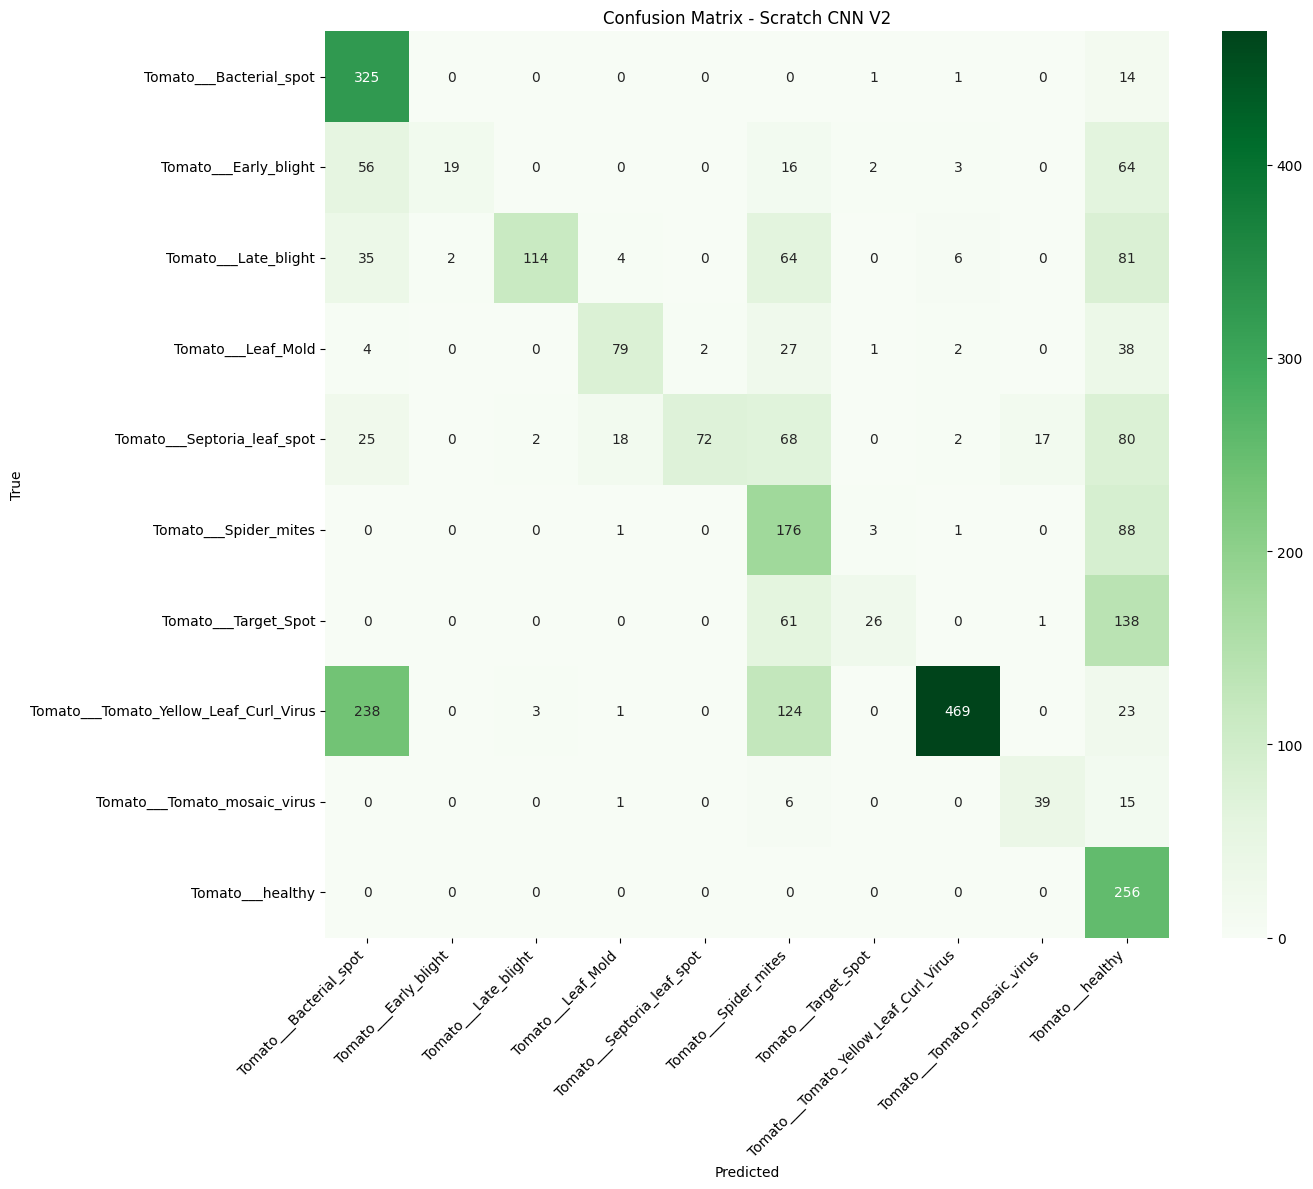


SCRATCH V2 READINESS DECISION
Acceptance rule: test_accuracy >= 85.00%
Observed v2_test_accuracy: 54.05%
FINAL DECISION: FAIL
Continue iterating (augment, architecture, class weighting, epochs).
Production model remains untouched.


In [14]:
# Save V2 model candidate
model_v2.save(SCRATCH_V2_MODEL_PATH)
print(f"Saved V2 scratch model to: {SCRATCH_V2_MODEL_PATH}")

# Evaluate V2 on test split
v2_test_loss, v2_test_accuracy = model_v2.evaluate(test_generator, verbose=1)
print("=" * 70)
print(f"V2 Test Loss: {v2_test_loss:.4f}")
print(f"V2 Test Accuracy: {v2_test_accuracy * 100:.2f}%")
print("=" * 70)

test_generator.reset()
y_prob_v2 = model_v2.predict(test_generator, verbose=1)
y_pred_v2 = np.argmax(y_prob_v2, axis=1)
y_true_v2 = test_generator.classes
class_names_v2 = list(test_generator.class_indices.keys())

print("\nV2 Classification Report:")
print(classification_report(y_true_v2, y_pred_v2, target_names=class_names_v2, digits=4))

cm_v2 = confusion_matrix(y_true_v2, y_pred_v2)
plt.figure(figsize=(14, 12))
sns.heatmap(
    cm_v2,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=class_names_v2,
    yticklabels=class_names_v2,
)
plt.title("Confusion Matrix - Scratch CNN V2")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("SCRATCH V2 READINESS DECISION")
print("=" * 70)
print(f"Acceptance rule: test_accuracy >= {PASS_ACCURACY * 100:.2f}%")
print(f"Observed v2_test_accuracy: {v2_test_accuracy * 100:.2f}%")
if v2_test_accuracy >= PASS_ACCURACY:
    print("FINAL DECISION: PASS")
    print(f"Candidate model for later replacement: {SCRATCH_V2_MODEL_PATH}")
else:
    print("FINAL DECISION: FAIL")
    print("Continue iterating (augment, architecture, class weighting, epochs).")
print("Production model remains untouched.")
print("=" * 70)